# 08 - 全链路瀑布图 (Full Chain Waterfall)

**目的**: 将每个组件的延迟汇总成一张完整的 Gantt 瀑布图，一眼看清瓶颈所在  
**数据来源**: 手动填入各 Notebook 测得的 P50 值，或自动读取最新 CSV  

**完整链路**:
```
用户发送消息
  │
  ├─ [01] Nginx 代理         ~2ms
  ├─ [02] API Gateway        ~10ms
  ├─ [03] AI Engine 路由     ~5ms
  ├─ [04] Session 读取       ~50ms  (PostgreSQL)
  ├─ [05] Embedding 计算     ~30ms  (sentence-transformers)
  │         ├─ Cache HIT     ~5ms   (Redis)
  │         └─ Cache MISS    ~30ms  (模型推理)
  ├─ [06] Qdrant 向量搜索    ~5ms
  ├─ [07] LLM 调用          ~2000ms (主要瓶颈)
  │         ├─ TTFB          ~800ms
  │         └─ 生成阶段      ~1200ms
  ├─ [08] Session 写入       ~50ms  (PostgreSQL)
  └─ [09] 响应序列化         ~5ms
用户收到响应
```

## 0. 数据填入（按需修改）

In [1]:
import os
import glob
from datetime import datetime

DATA_DIR = "../data"
os.makedirs(DATA_DIR, exist_ok=True)

# =============================================
# 方式一：手动填入各组件 P50 延迟（ms）
# 运行其他 Notebook 后，把测量值填入下方
# =============================================
MANUAL_BASELINE = {
    # 基础设施（来自 Notebook 04）
    "nginx_proxy":       2.0,    # Nginx 代理开销
    "api_gateway":       10.0,   # API Gateway 路由 + GraphQL 解析
    "engine_routing":    5.0,    # AI Engine 内部路由
    "session_read_pg":   50.0,   # PostgreSQL session 读取
    "session_write_pg":  55.0,   # PostgreSQL session 写入
    "redis_cache_hit":   5.0,    # Redis GET（命中）
    "redis_cache_miss":  8.0,    # Redis GET+SET（未命中，不含推理）

    # Embedding（来自 Notebook 05）
    "embedding_medium":  30.0,   # 中等文本 embedding（未命中缓存）

    # Qdrant（来自 Notebook 06）
    "qdrant_search_5":   5.0,    # top_k=5 向量搜索

    # LLM（来自 Notebook 07）
    "llm_ttfb":          800.0,  # TTFB（首字节）
    "llm_generation":    1200.0, # 生成阶段
    "llm_total":         2000.0, # LLM 总延迟
}

# =============================================
# 方式二：尝试从 CSV 自动读取最新数据
# =============================================
AUTO_LOAD = True   # 设为 False 时完全使用上方手动数据

print("配置加载完成")
print(f"AUTO_LOAD: {AUTO_LOAD}")

配置加载完成
AUTO_LOAD: True


## 1. 依赖导入

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.patches as mpatches

matplotlib.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

print("依赖导入完成")

依赖导入完成


## 2. 尝试自动加载最新测量数据

In [3]:
baseline = dict(MANUAL_BASELINE)  # 从手动值开始，逐步用实测数据覆盖

def get_latest_csv(pattern: str) -> pd.DataFrame:
    files = sorted(glob.glob(f"{DATA_DIR}/{pattern}"), reverse=True)
    if files:
        df = pd.read_csv(files[0])
        print(f"  已加载: {files[0]} ({len(df)} 条记录)")
        return df
    return None


if AUTO_LOAD:
    print("尝试自动加载测量数据...")

    # 从 04-infrastructure-baseline
    df_infra = get_latest_csv("infra_baseline_*.csv")
    if df_infra is not None:
        try:
            # Redis ping
            redis_hit = df_infra[(df_infra.get("scenario", "") == "get") & (df_infra.get("success", False))]["latency_ms"]
            if len(redis_hit) > 0:
                baseline["redis_cache_hit"] = np.percentile(redis_hit, 50)
                print(f"  更新 redis_cache_hit: {baseline['redis_cache_hit']:.1f}ms")

            # PG ping
            pg_ping = df_infra[(df_infra.get("scenario", "") == "ping") & (df_infra.get("success", False))]["latency_ms"]
            if len(pg_ping) > 0:
                baseline["session_read_pg"] = np.percentile(pg_ping, 50)
                print(f"  更新 session_read_pg: {baseline['session_read_pg']:.1f}ms")
        except Exception as e:
            print(f"  解析 infra 数据时出错: {e}")

    # 从 06-vector-search-deep
    df_qdrant = get_latest_csv("vector_search_*.csv")
    if df_qdrant is not None:
        try:
            search_data = df_qdrant[(df_qdrant.get("success", False) == True)]
            if "top_k" in search_data.columns:
                search5 = search_data[search_data["top_k"] == 5]["latency_ms"]
                if len(search5) > 0:
                    baseline["qdrant_search_5"] = np.percentile(search5, 50)
                    print(f"  更新 qdrant_search_5: {baseline['qdrant_search_5']:.1f}ms")
        except Exception as e:
            print(f"  解析 qdrant 数据时出错: {e}")

    # 从 07-llm-internals
    df_llm = get_latest_csv("llm_internals_*.csv")
    if df_llm is not None:
        try:
            llm_ok = df_llm[df_llm.get("success", False) == True]
            if len(llm_ok) > 0:
                baseline["llm_total"] = np.percentile(llm_ok["latency_ms"], 50)
                ttfb_data = llm_ok["ttfb_ms"].dropna()
                if len(ttfb_data) > 0:
                    baseline["llm_ttfb"] = np.percentile(ttfb_data, 50)
                    baseline["llm_generation"] = baseline["llm_total"] - baseline["llm_ttfb"]
                print(f"  更新 llm_total: {baseline['llm_total']:.0f}ms")
                print(f"  更新 llm_ttfb: {baseline['llm_ttfb']:.0f}ms")
        except Exception as e:
            print(f"  解析 LLM 数据时出错: {e}")

print(f"\n最终基线数据:")
for k, v in baseline.items():
    print(f"  {k:30s}: {v:.1f} ms")

尝试自动加载测量数据...

最终基线数据:
  nginx_proxy                   : 2.0 ms
  api_gateway                   : 10.0 ms
  engine_routing                : 5.0 ms
  session_read_pg               : 50.0 ms
  session_write_pg              : 55.0 ms
  redis_cache_hit               : 5.0 ms
  redis_cache_miss              : 8.0 ms
  embedding_medium              : 30.0 ms
  qdrant_search_5               : 5.0 ms
  llm_ttfb                      : 800.0 ms
  llm_generation                : 1200.0 ms
  llm_total                     : 2000.0 ms


## 3. 构建链路时序数据

In [4]:
# 场景 A: Cache HIT（最优路径）
chain_cache_hit = [
    # (步骤名, 耗时ms, 颜色, 层级)
    ("[01] Nginx 代理",        baseline["nginx_proxy"],      "#4CAF50", 0),
    ("[02] API Gateway",       baseline["api_gateway"],      "#4CAF50", 0),
    ("[03] Engine 路由",       baseline["engine_routing"],   "#4CAF50", 0),
    ("[04] Session 读取(PG)",  baseline["session_read_pg"],  "#FF9800", 1),
    ("[05] Embedding(Cache)",  baseline["redis_cache_hit"],  "#2196F3", 2),
    ("[06] Qdrant 搜索",       baseline["qdrant_search_5"],  "#9C27B0", 1),
    ("[07] LLM TTFB",          baseline["llm_ttfb"],         "#F44336", 3),
    ("[07] LLM 生成",          baseline["llm_generation"],   "#E91E63", 3),
    ("[08] Session 写入(PG)",  baseline["session_write_pg"], "#FF9800", 1),
    ("[09] 响应序列化",        5.0,                          "#4CAF50", 0),
]

# 场景 B: Cache MISS（正常路径）
chain_cache_miss = [
    ("[01] Nginx 代理",         baseline["nginx_proxy"],      "#4CAF50", 0),
    ("[02] API Gateway",        baseline["api_gateway"],      "#4CAF50", 0),
    ("[03] Engine 路由",        baseline["engine_routing"],   "#4CAF50", 0),
    ("[04] Session 读取(PG)",   baseline["session_read_pg"],  "#FF9800", 1),
    ("[05a] Cache Miss Check",  baseline["redis_cache_miss"], "#2196F3", 2),
    ("[05b] Embedding 推理",    baseline["embedding_medium"], "#03A9F4", 2),
    ("[05c] Cache 写入",        baseline["redis_cache_miss"], "#2196F3", 2),
    ("[06] Qdrant 搜索",        baseline["qdrant_search_5"],  "#9C27B0", 1),
    ("[07] LLM TTFB",           baseline["llm_ttfb"],         "#F44336", 3),
    ("[07] LLM 生成",           baseline["llm_generation"],   "#E91E63", 3),
    ("[08] Session 写入(PG)",   baseline["session_write_pg"], "#FF9800", 1),
    ("[09] 响应序列化",         5.0,                          "#4CAF50", 0),
]

def compute_timeline(chain):
    timeline = []
    t = 0
    for name, duration, color, tier in chain:
        timeline.append({"name": name, "start": t, "duration": duration, "end": t + duration, "color": color, "tier": tier})
        t += duration
    return pd.DataFrame(timeline)

df_hit = compute_timeline(chain_cache_hit)
df_miss = compute_timeline(chain_cache_miss)

print("链路时序数据:")
print("\n[Cache HIT 路径]")
print(f"  总延迟: {df_hit['end'].max():.0f} ms")
print(df_hit[["name", "start", "duration", "end"]].to_string(index=False))

print("\n[Cache MISS 路径]")
print(f"  总延迟: {df_miss['end'].max():.0f} ms")
print(df_miss[["name", "start", "duration", "end"]].to_string(index=False))

链路时序数据:

[Cache HIT 路径]
  总延迟: 2137 ms
                 name  start  duration    end
        [01] Nginx 代理    0.0       2.0    2.0
     [02] API Gateway    2.0      10.0   12.0
       [03] Engine 路由   12.0       5.0   17.0
  [04] Session 读取(PG)   17.0      50.0   67.0
[05] Embedding(Cache)   67.0       5.0   72.0
       [06] Qdrant 搜索   72.0       5.0   77.0
        [07] LLM TTFB   77.0     800.0  877.0
          [07] LLM 生成  877.0    1200.0 2077.0
  [08] Session 写入(PG) 2077.0      55.0 2132.0
           [09] 响应序列化 2132.0       5.0 2137.0

[Cache MISS 路径]
  总延迟: 2178 ms
                  name  start  duration    end
         [01] Nginx 代理    0.0       2.0    2.0
      [02] API Gateway    2.0      10.0   12.0
        [03] Engine 路由   12.0       5.0   17.0
   [04] Session 读取(PG)   17.0      50.0   67.0
[05a] Cache Miss Check   67.0       8.0   75.0
    [05b] Embedding 推理   75.0      30.0  105.0
        [05c] Cache 写入  105.0       8.0  113.0
        [06] Qdrant 搜索  113.0       5.0  118.0


## 4. 瀑布图（Gantt Chart）

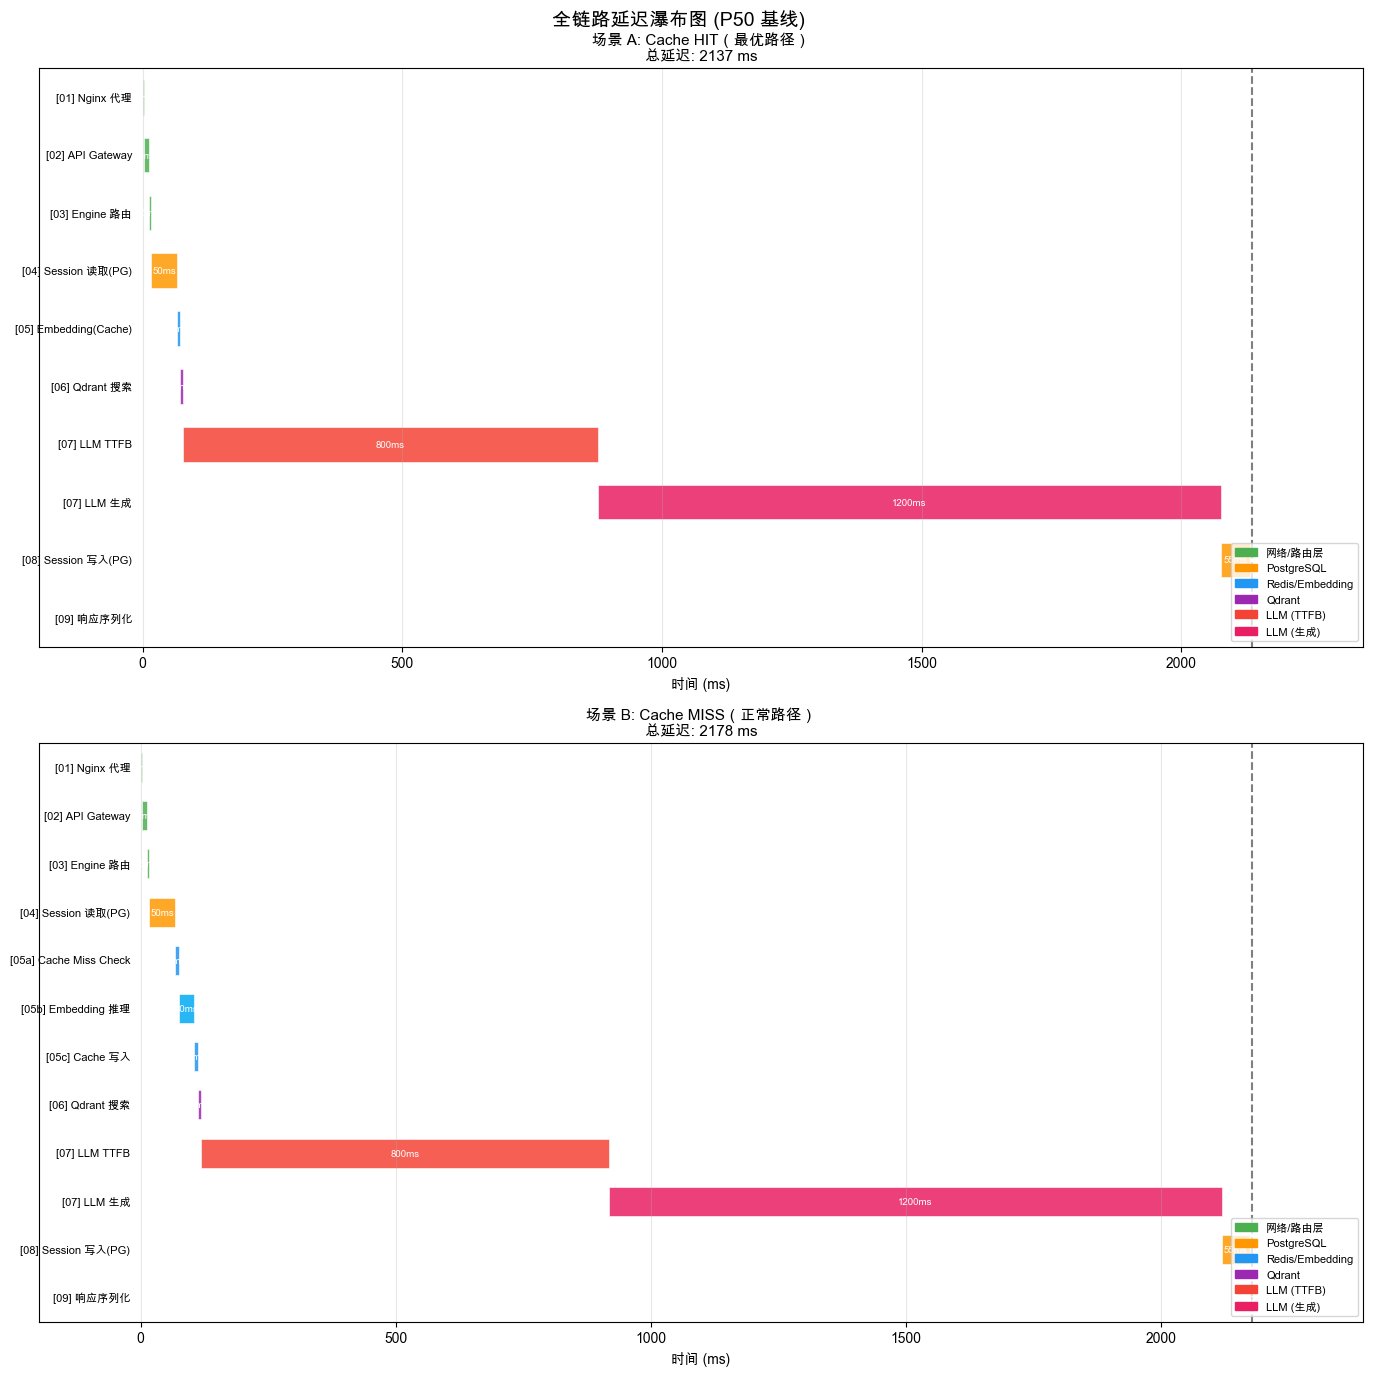

图表已保存: ../data/full_chain_waterfall_20260219_1023.png


In [5]:
def draw_waterfall(ax, df_chain, title: str):
    """绘制链路瀑布图"""
    n_steps = len(df_chain)
    y_positions = range(n_steps - 1, -1, -1)  # 从上到下

    for i, (_, row) in enumerate(df_chain.iterrows()):
        y = n_steps - 1 - i
        bar = ax.barh(y, row["duration"], left=row["start"],
                      color=row["color"], alpha=0.85, height=0.6,
                      edgecolor="white", linewidth=0.5)

        # 步骤名称（左侧）
        ax.text(-20, y, row["name"], ha="right", va="center", fontsize=8)

        # 耗时标注
        mid_x = row["start"] + row["duration"] / 2
        ax.text(mid_x, y, f"{row['duration']:.0f}ms",
                ha="center", va="center", fontsize=7, color="white", fontweight="bold")

    total_ms = df_chain["end"].max()
    ax.set_xlim(-200, total_ms * 1.1)
    ax.set_ylim(-0.5, n_steps - 0.5)
    ax.set_yticks([])
    ax.set_xlabel("时间 (ms)", fontsize=10)
    ax.set_title(f"{title}\n总延迟: {total_ms:.0f} ms", fontsize=11)
    ax.axvline(total_ms, color="black", linestyle="--", alpha=0.5, label=f"总计: {total_ms:.0f}ms")
    ax.grid(axis="x", alpha=0.3)

    # 图例（颜色分类）
    legend_items = [
        mpatches.Patch(color="#4CAF50", label="网络/路由层"),
        mpatches.Patch(color="#FF9800", label="PostgreSQL"),
        mpatches.Patch(color="#2196F3", label="Redis/Embedding"),
        mpatches.Patch(color="#9C27B0", label="Qdrant"),
        mpatches.Patch(color="#F44336", label="LLM (TTFB)"),
        mpatches.Patch(color="#E91E63", label="LLM (生成)"),
    ]
    ax.legend(handles=legend_items, loc="lower right", fontsize=8)


fig, axes = plt.subplots(2, 1, figsize=(14, 14))
fig.suptitle("全链路延迟瀑布图 (P50 基线)", fontsize=14, fontweight="bold")

draw_waterfall(axes[0], df_hit, "场景 A: Cache HIT（最优路径）")
draw_waterfall(axes[1], df_miss, "场景 B: Cache MISS（正常路径）")

plt.tight_layout()
chart_file = f"../data/full_chain_waterfall_{datetime.now().strftime('%Y%m%d_%H%M')}.png"
plt.savefig(chart_file, dpi=150, bbox_inches="tight")
plt.show()
print(f"图表已保存: {chart_file}")

## 5. 瓶颈分析与优化优先级

In [6]:
print("=" * 70)
print("瓶颈分析 (Cache MISS 路径)")
print("=" * 70)

total_miss = df_miss["end"].max()
total_hit = df_hit["end"].max()

# 按耗时排序
df_miss_sorted = df_miss.sort_values("duration", ascending=False).reset_index(drop=True)

print(f"\n总延迟 (Cache MISS): {total_miss:.0f} ms")
print(f"总延迟 (Cache HIT):  {total_hit:.0f} ms")
print(f"Cache 加速效果:       -{total_miss - total_hit:.0f} ms ({(total_miss - total_hit)/total_miss*100:.1f}%)")
print()
print("各步骤占比 (Cache MISS):")
for _, row in df_miss_sorted.iterrows():
    pct = row["duration"] / total_miss * 100
    bar = "█" * int(pct / 2)
    print(f"  {row['name']:30s}: {row['duration']:6.0f}ms ({pct:5.1f}%) {bar}")

print()
print("=" * 70)
print("优化优先级（基于影响面 × 可优化空间）")
print("=" * 70)

llm_pct = (baseline["llm_total"] / total_miss * 100)
pg_pct   = ((baseline["session_read_pg"] + baseline["session_write_pg"]) / total_miss * 100)
emb_pct  = (baseline["embedding_medium"] / total_miss * 100)

optimizations = [
    {
        "rank": 1,
        "target": "LLM 调用",
        "current_ms": baseline["llm_total"],
        "proportion": f"{llm_pct:.0f}%",
        "action": "并发探测多 Provider，选最快；缩短 failover 超时 30s→5s",
        "expected_saving": "0ms (正常) / -250s (failover 时)",
        "issue": "ENGINE-034",
    },
    {
        "rank": 2,
        "target": "PostgreSQL 会话",
        "current_ms": baseline["session_read_pg"] + baseline["session_write_pg"],
        "proportion": f"{pg_pct:.0f}%",
        "action": "Redis Session Cache（读优先 Redis，写异步 PG）",
        "expected_saving": f"-{(baseline['session_read_pg'] + baseline['session_write_pg']) * 0.8:.0f}ms",
        "issue": "ENGINE-035 (待创建)",
    },
    {
        "rank": 3,
        "target": "Embedding 推理",
        "current_ms": baseline["embedding_medium"],
        "proportion": f"{emb_pct:.0f}%",
        "action": "提高 Cache 命中率（扩展 TTL）；批量预热常见品类词",
        "expected_saving": f"-{baseline['embedding_medium'] * 0.9:.0f}ms (命中时)",
        "issue": "ENGINE-036 (待创建)",
    },
]

for opt in optimizations:
    print(f"\n[P{opt['rank']}] {opt['target']} ({opt['proportion']} 占比)")
    print(f"  当前耗时: {opt['current_ms']:.0f} ms")
    print(f"  优化方案: {opt['action']}")
    print(f"  预期节省: {opt['expected_saving']}")
    print(f"  关联 Issue: {opt['issue']}")

print("\n=" * 70)

瓶颈分析 (Cache MISS 路径)

总延迟 (Cache MISS): 2178 ms
总延迟 (Cache HIT):  2137 ms
Cache 加速效果:       -41 ms (1.9%)

各步骤占比 (Cache MISS):
  [07] LLM 生成                   :   1200ms ( 55.1%) ███████████████████████████
  [07] LLM TTFB                 :    800ms ( 36.7%) ██████████████████
  [08] Session 写入(PG)           :     55ms (  2.5%) █
  [04] Session 读取(PG)           :     50ms (  2.3%) █
  [05b] Embedding 推理            :     30ms (  1.4%) 
  [02] API Gateway              :     10ms (  0.5%) 
  [05a] Cache Miss Check        :      8ms (  0.4%) 
  [05c] Cache 写入                :      8ms (  0.4%) 
  [03] Engine 路由                :      5ms (  0.2%) 
  [06] Qdrant 搜索                :      5ms (  0.2%) 
  [09] 响应序列化                    :      5ms (  0.2%) 
  [01] Nginx 代理                 :      2ms (  0.1%) 

优化优先级（基于影响面 × 可优化空间）

[P1] LLM 调用 (92% 占比)
  当前耗时: 2000 ms
  优化方案: 并发探测多 Provider，选最快；缩短 failover 超时 30s→5s
  预期节省: 0ms (正常) / -250s (failover 时)
  关联 Issue: ENGINE-034

[P2] PostgreSQL 会话 

## 6. 多 Provider 链路对比

不同 LLM Provider 的全链路预估总延迟
基础开销 (非LLM, Cache HIT): 137 ms

  APIPro/Claude       : LLM= 2000ms + 开销=137ms = 总计 2137ms
  APIPro/Qwen         : LLM= 1200ms + 开销=137ms = 总计 1337ms
  APIPro/DeepSeek     : LLM= 1500ms + 开销=137ms = 总计 1637ms
  Ollama/14b          : LLM= 8000ms + 开销=137ms = 总计 8137ms
  Ollama/7b           : LLM= 4000ms + 开销=137ms = 总计 4137ms


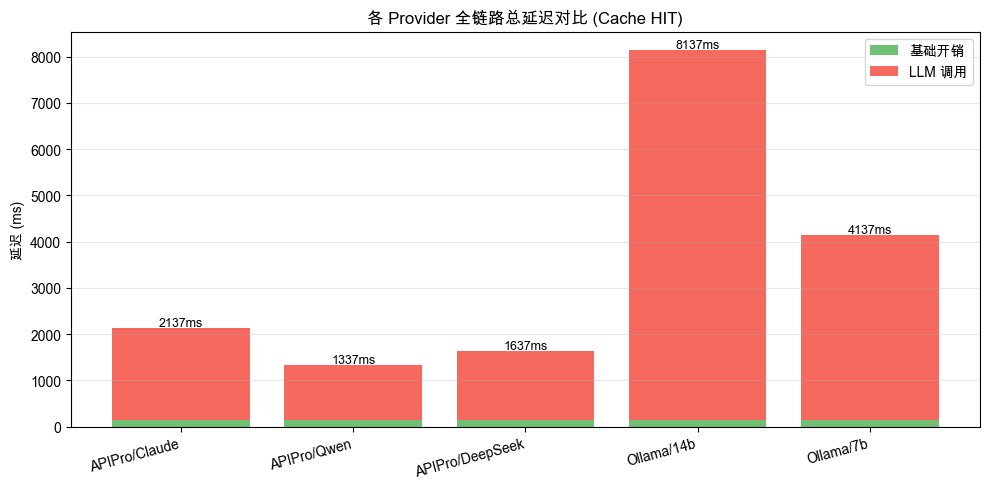

图表已保存: ../data/provider_total_latency_20260219_1024.png


In [7]:
# 假设不同 Provider 的 LLM 延迟（从 Notebook 07 获取）
# 可在此手动填入实测值
PROVIDER_LLM_LATENCY = {
    "APIPro/Claude": baseline.get("llm_total", 2000),
    "APIPro/Qwen":   1200,  # 通常更快
    "APIPro/DeepSeek": 1500,
    "Ollama/14b":    8000,  # 本地 CPU 推理
    "Ollama/7b":     4000,
}

# 非 LLM 部分（Cache HIT 路径）
non_llm_overhead = total_hit - baseline["llm_total"]

print("=" * 55)
print("不同 LLM Provider 的全链路预估总延迟")
print("=" * 55)
print(f"基础开销 (非LLM, Cache HIT): {non_llm_overhead:.0f} ms")
print()

provider_totals = []
for provider, llm_ms in PROVIDER_LLM_LATENCY.items():
    total = non_llm_overhead + llm_ms
    provider_totals.append({"provider": provider, "llm_ms": llm_ms, "overhead_ms": non_llm_overhead, "total_ms": total})
    print(f"  {provider:20s}: LLM={llm_ms:5.0f}ms + 开销={non_llm_overhead:.0f}ms = 总计 {total:.0f}ms")

# 可视化
df_providers = pd.DataFrame(provider_totals)
fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(df_providers))
ax.bar(x, df_providers["overhead_ms"], label="基础开销", color="#4CAF50", alpha=0.8)
ax.bar(x, df_providers["llm_ms"], bottom=df_providers["overhead_ms"], label="LLM 调用", color="#F44336", alpha=0.8)
ax.set_xticks(list(x))
ax.set_xticklabels(df_providers["provider"], rotation=15, ha="right")
ax.set_ylabel("延迟 (ms)")
ax.set_title("各 Provider 全链路总延迟对比 (Cache HIT)")
ax.legend()
ax.grid(axis="y", alpha=0.3)

for i, row in df_providers.iterrows():
    ax.text(i, row["total_ms"] + 50, f"{row['total_ms']:.0f}ms", ha='center', fontsize=9)

plt.tight_layout()
chart_file2 = f"../data/provider_total_latency_{datetime.now().strftime('%Y%m%d_%H%M')}.png"
plt.savefig(chart_file2, dpi=150, bbox_inches="tight")
plt.show()
print(f"图表已保存: {chart_file2}")

## 7. 基线快照保存

In [8]:
import json

snapshot = {
    "timestamp": datetime.now().isoformat(),
    "baseline_ms": baseline,
    "chain_totals": {
        "cache_hit_ms": float(df_hit["end"].max()),
        "cache_miss_ms": float(df_miss["end"].max()),
    },
    "provider_totals": {row["provider"]: float(row["total_ms"]) for _, row in df_providers.iterrows()},
    "bottlenecks": [
        {"rank": opt["rank"], "target": opt["target"], "issue": opt["issue"]}
        for opt in optimizations
    ]
}

snapshot_file = f"{DATA_DIR}/full_chain_baseline_{datetime.now().strftime('%Y%m%d_%H%M')}.json"
with open(snapshot_file, "w", encoding="utf-8") as f:
    json.dump(snapshot, f, ensure_ascii=False, indent=2)

print(f"基线快照已保存: {snapshot_file}")
print()
print("=" * 55)
print("全链路基线总结")
print("=" * 55)
print(f"Cache HIT  路径: {snapshot['chain_totals']['cache_hit_ms']:.0f} ms")
print(f"Cache MISS 路径: {snapshot['chain_totals']['cache_miss_ms']:.0f} ms")
print(f"最快 Provider:   {min(snapshot['provider_totals'], key=lambda k: snapshot['provider_totals'][k])}")
print(f"主要瓶颈:         LLM 调用 ({llm_pct:.0f}% 占比)")

基线快照已保存: ../data/full_chain_baseline_20260219_1024.json

全链路基线总结
Cache HIT  路径: 2137 ms
Cache MISS 路径: 2178 ms
最快 Provider:   APIPro/Qwen
主要瓶颈:         LLM 调用 (92% 占比)
